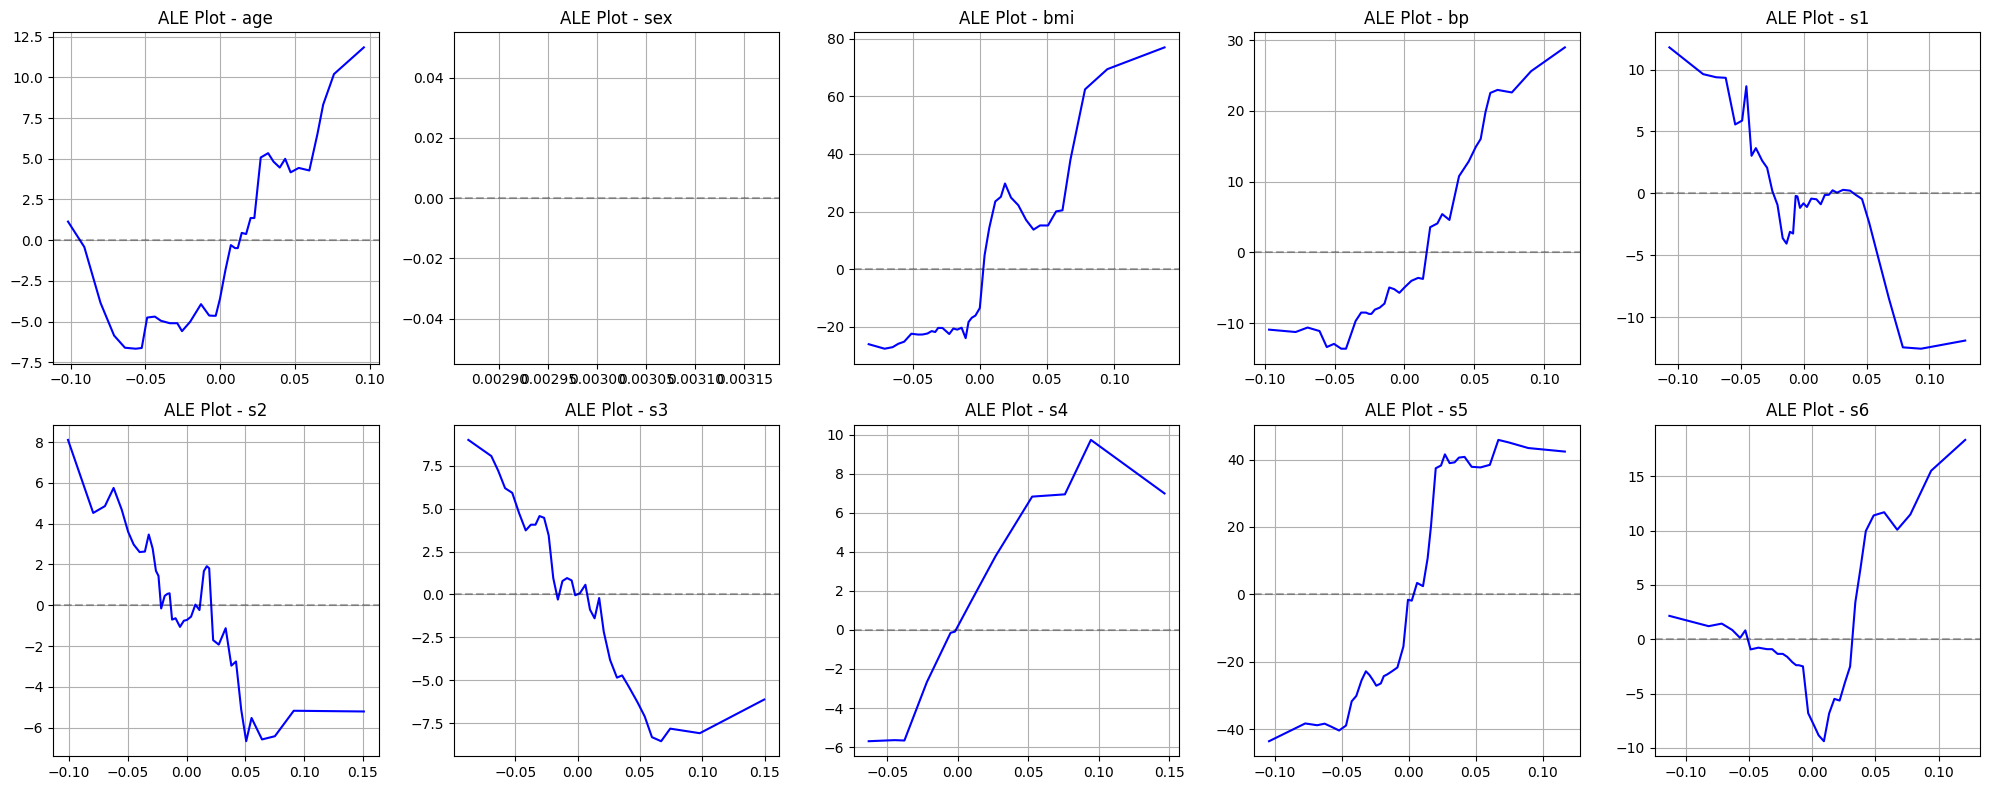


Feature Importances:
  Feature  Importance
2     bmi    0.355469
8      s5    0.230957
3      bp    0.088408
9      s6    0.071329
0     age    0.058642
5      s2    0.057227
4      s1    0.052784
6      s3    0.051339
7      s4    0.024213
1     sex    0.009633


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

def compute_ale(model, X, feature_idx, bins=40):
    """
    Compute Accumulated Local Effects for a single feature

    Parameters:
    -----------
    model : fitted model with predict method
    X : feature matrix
    feature_idx : index of the feature to analyze
    bins : number of bins for feature values

    Returns:
    --------
    centers : bin centers for plotting
    ale_values : ALE values for each bin
    """
    feature_values = X[:, feature_idx]
    quantiles = np.percentile(feature_values, np.linspace(0, 100, bins+1))

    # Ensure unique bin edges
    quantiles = np.unique(quantiles)
    bins = len(quantiles) - 1

    # Initialize ALE values
    ale_values = np.zeros(bins)
    counts = np.zeros(bins)

    # Compute local effects for each bin
    for i in range(bins):
        bin_indices = (feature_values >= quantiles[i]) & (feature_values < quantiles[i + 1])
        if not np.any(bin_indices):
            continue

        X_bin = X[bin_indices].copy()
        n_instances = X_bin.shape[0]

        # Compute predictions for both ends of the bin
        X_plus = X_bin.copy()
        X_minus = X_bin.copy()
        X_plus[:, feature_idx] = quantiles[i + 1]
        X_minus[:, feature_idx] = quantiles[i]

        # Calculate average difference in predictions
        delta = model.predict(X_plus) - model.predict(X_minus)
        ale_values[i] = np.mean(delta)
        counts[i] = n_instances

    # Accumulate effects
    ale_values = np.cumsum(ale_values)

    # Center ALE values to have mean of 0
    ale_values = ale_values - np.average(ale_values, weights=counts)

    # Calculate bin centers for plotting
    centers = (quantiles[1:] + quantiles[:-1]) / 2

    return centers, ale_values

# Load and prepare data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Create ALE plots for each feature
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

for idx, (feature_name, ax) in enumerate(zip(feature_names, axes)):
    centers, ale_values = compute_ale(rf, X, idx)

    ax.plot(centers, ale_values, '-', color='blue')
    ax.set_title(f'ALE Plot - {feature_name}')
    ax.grid(True)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print feature importances
importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
})
print("\nFeature Importances:")
print(importances.sort_values('Importance', ascending=False))

/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


R² score on test set: 0.491


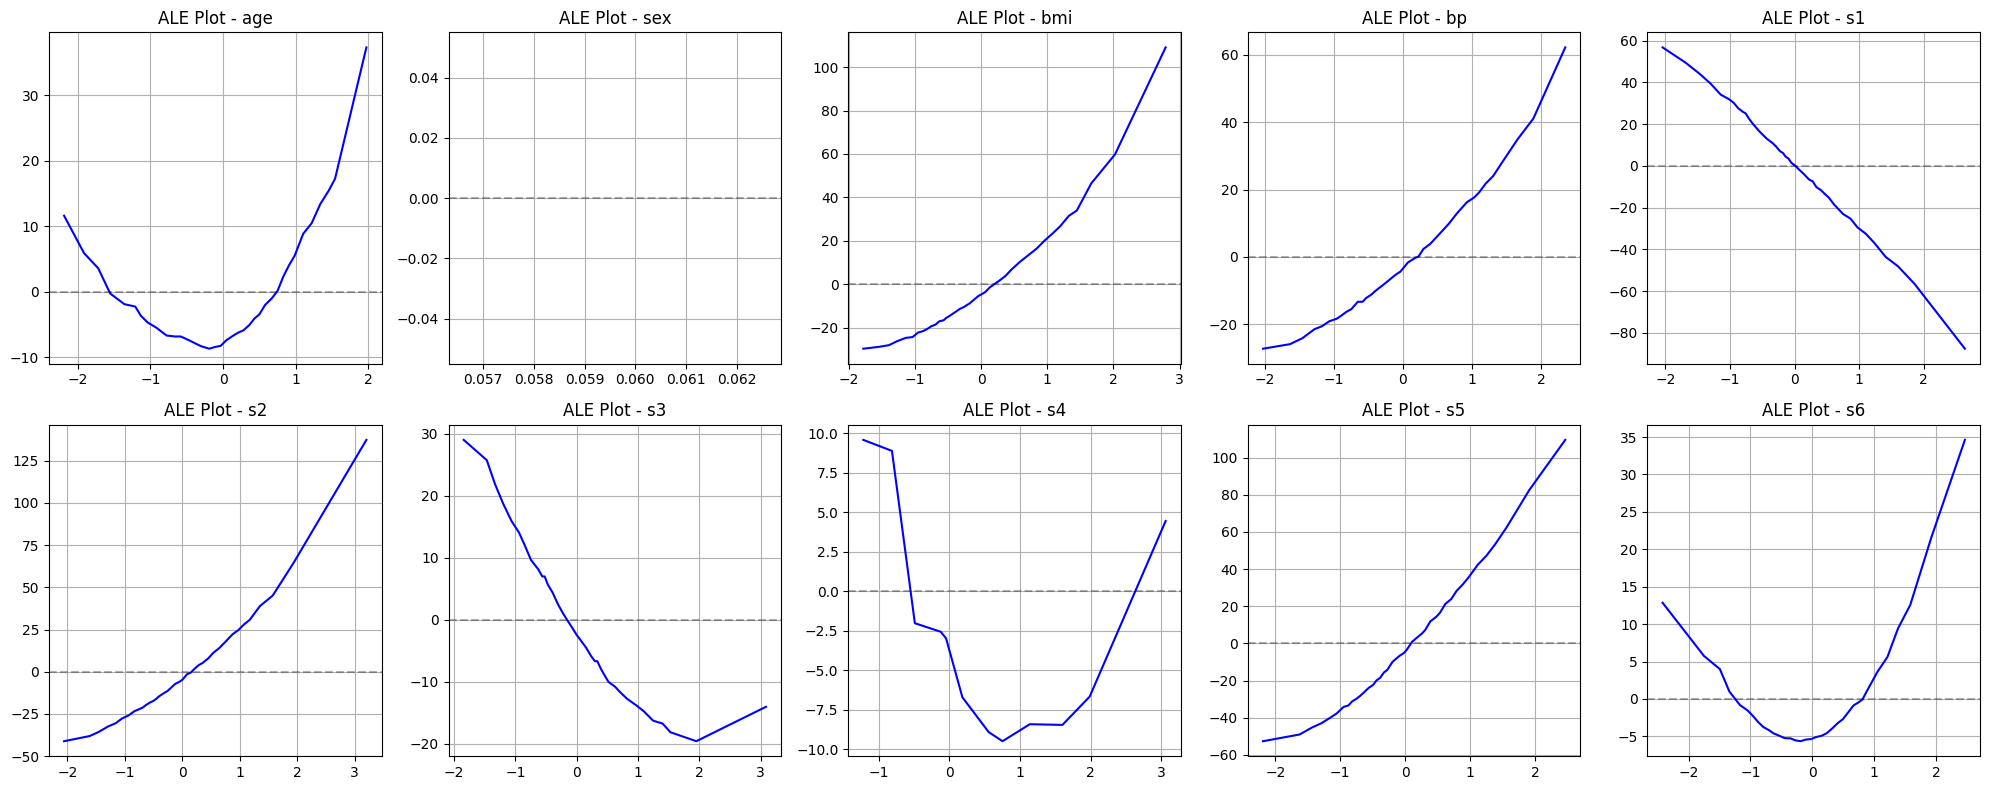


Feature Effects Summary (sorted by magnitude):
  Feature  Effect Range
5      s2    178.571922
8      s5    162.177841
4      s1    144.438523
2     bmi    138.796821
3      bp     89.472414
6      s3     48.571990
0     age     46.012679
9      s6     40.264364
7      s4     19.058020
1     sex      0.000000


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt

def compute_ale(model, X, feature_idx, bins=40):
    """
    Compute Accumulated Local Effects for a single feature

    Parameters:
    -----------
    model : fitted model with predict method
    X : feature matrix
    feature_idx : index of the feature to analyze
    bins : number of bins for feature values

    Returns:
    --------
    centers : bin centers for plotting
    ale_values : ALE values for each bin
    """
    feature_values = X[:, feature_idx]
    quantiles = np.percentile(feature_values, np.linspace(0, 100, bins+1))

    # Ensure unique bin edges
    quantiles = np.unique(quantiles)
    bins = len(quantiles) - 1

    # Initialize ALE values
    ale_values = np.zeros(bins)
    counts = np.zeros(bins)

    # Compute local effects for each bin
    for i in range(bins):
        bin_indices = (feature_values >= quantiles[i]) & (feature_values < quantiles[i + 1])
        if not np.any(bin_indices):
            continue

        X_bin = X[bin_indices].copy()
        n_instances = X_bin.shape[0]

        # Compute predictions for both ends of the bin
        X_plus = X_bin.copy()
        X_minus = X_bin.copy()
        X_plus[:, feature_idx] = quantiles[i + 1]
        X_minus[:, feature_idx] = quantiles[i]

        # Calculate average difference in predictions
        delta = model.predict(X_plus) - model.predict(X_minus)
        ale_values[i] = np.mean(delta)
        counts[i] = n_instances

    # Accumulate effects
    ale_values = np.cumsum(ale_values)

    # Center ALE values to have mean of 0
    ale_values = ale_values - np.average(ale_values, weights=counts)

    # Calculate bin centers for plotting
    centers = (quantiles[1:] + quantiles[:-1]) / 2

    return centers, ale_values

# Load and prepare data
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

# Split data and scale features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train neural network
nn = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # Due strati interni con 64 e 32 neuroni
    activation='relu',            # Funzione di attivazione ReLU
    solver='adam',               # Ottimizzatore Adam
    max_iter=1000,              # Numero massimo di iterazioni
    random_state=42
)

nn.fit(X_train_scaled, y_train)

# Print model score
print(f"R² score on test set: {nn.score(X_test_scaled, y_test):.3f}")

# Create ALE plots for each feature
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.ravel()

# Compute and plot ALE for each feature
for idx, (feature_name, ax) in enumerate(zip(feature_names, axes)):
    centers, ale_values = compute_ale(nn, X_train_scaled, idx)

    ax.plot(centers, ale_values, '-', color='blue')
    ax.set_title(f'ALE Plot - {feature_name}')
    ax.grid(True)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print feature effects summary
feature_effects = []
for idx, feature_name in enumerate(feature_names):
    centers, ale_values = compute_ale(nn, X_train_scaled, idx)
    effect_range = np.max(ale_values) - np.min(ale_values)
    feature_effects.append({
        'Feature': feature_name,
        'Effect Range': effect_range
    })

effects_df = pd.DataFrame(feature_effects)
print("\nFeature Effects Summary (sorted by magnitude):")
print(effects_df.sort_values('Effect Range', ascending=False))

In [6]:
!pip -q install PyALE

INFO:PyALE._ALE_generic:Continuous feature detected.
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
INFO:PyALE._ALE_generic:Discrete feature detected.
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
INFO:PyALE._ALE_generic:Continuous featur

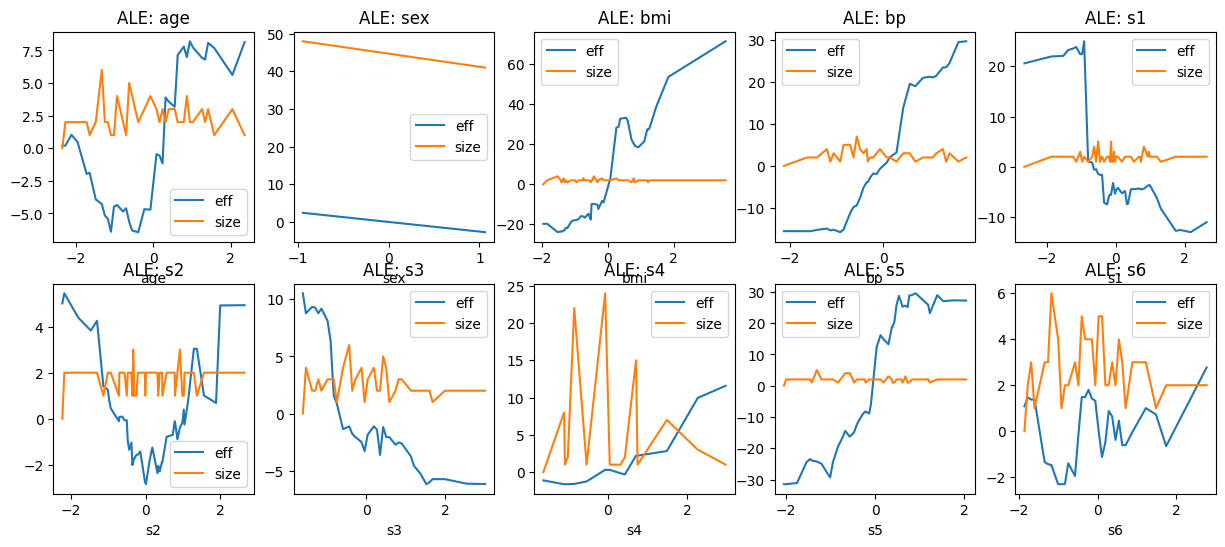

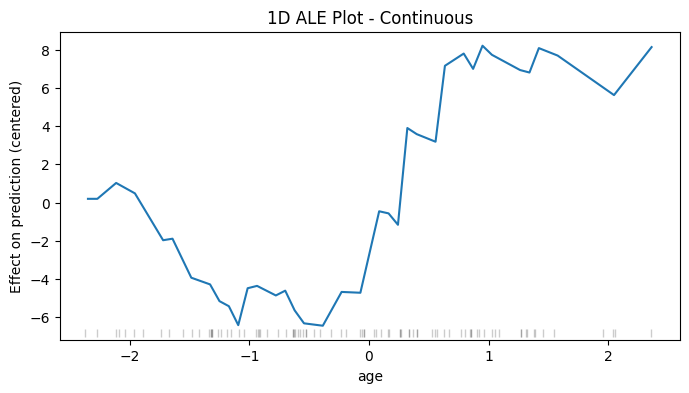

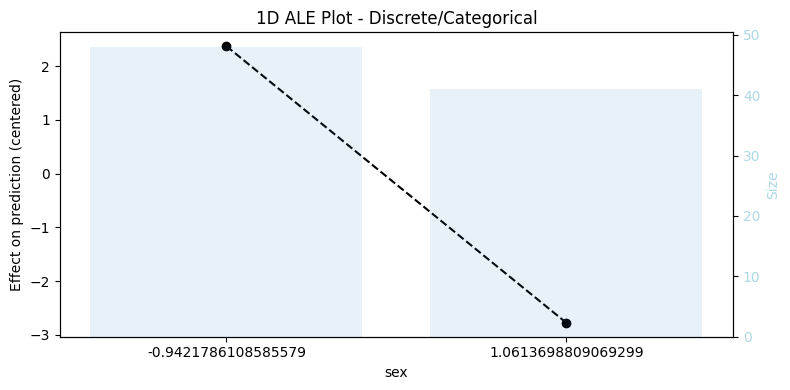

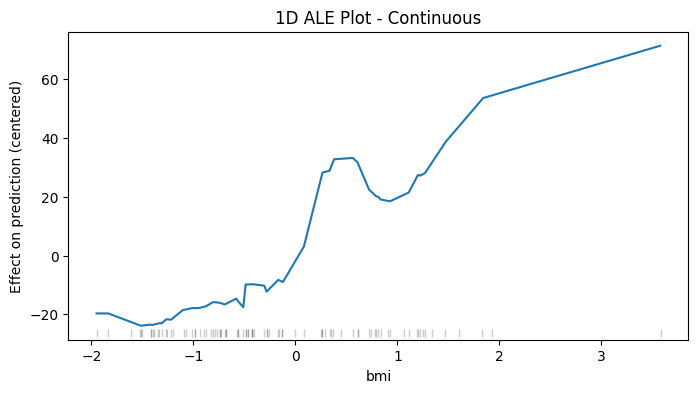

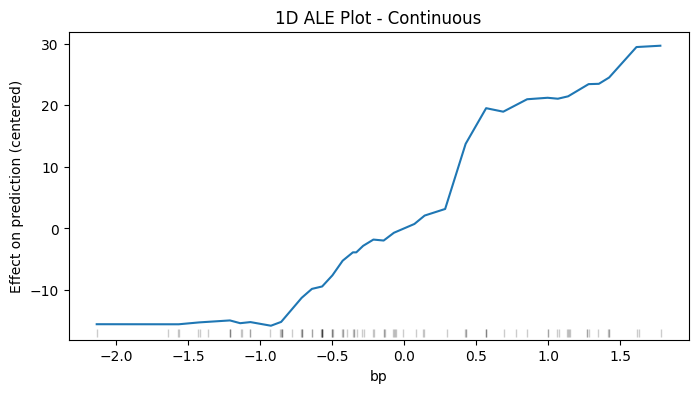

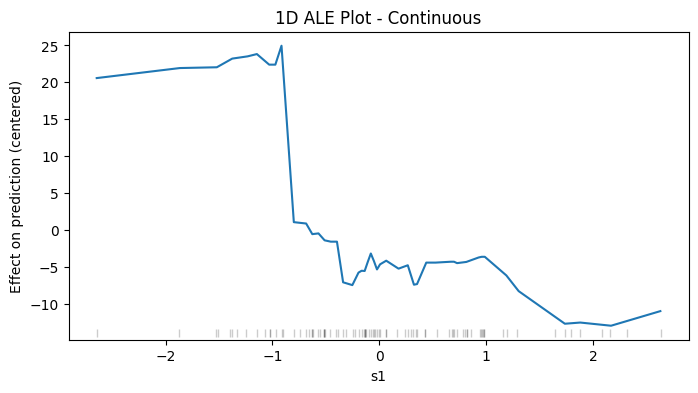

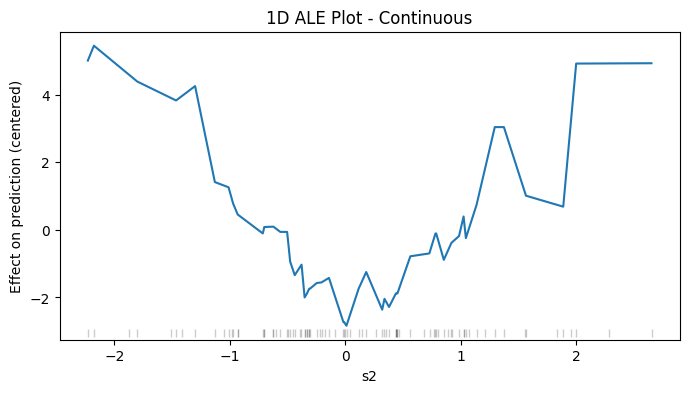

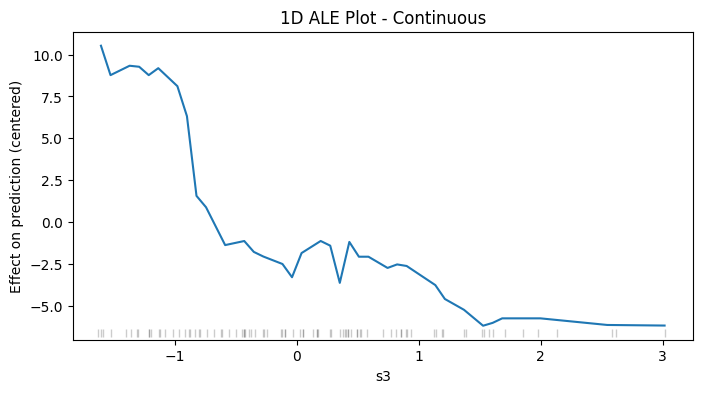

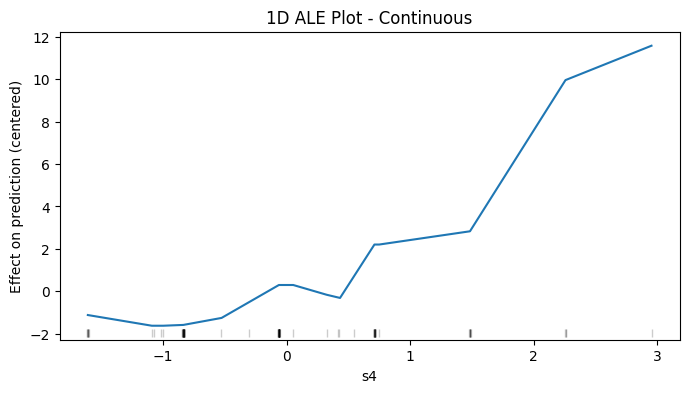

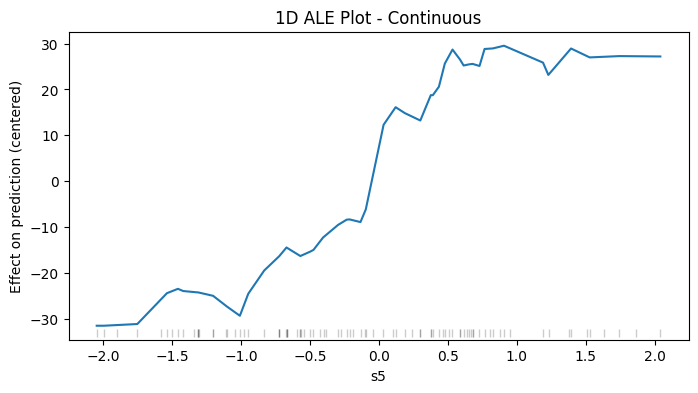

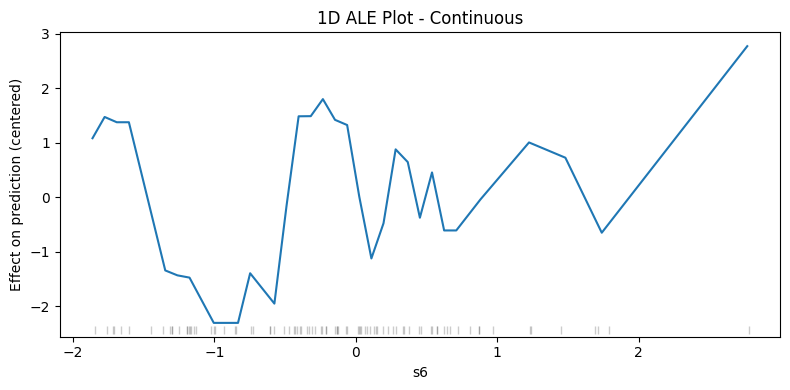

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without featu

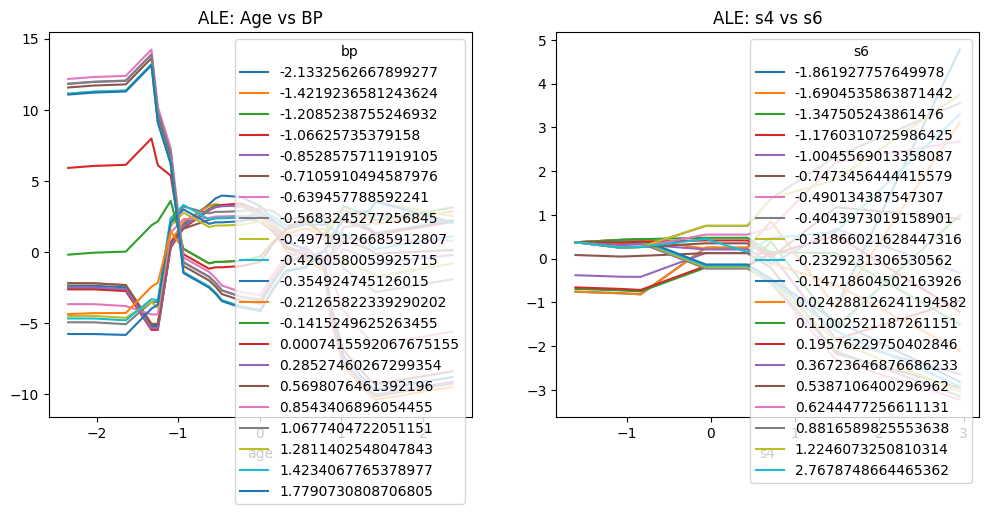

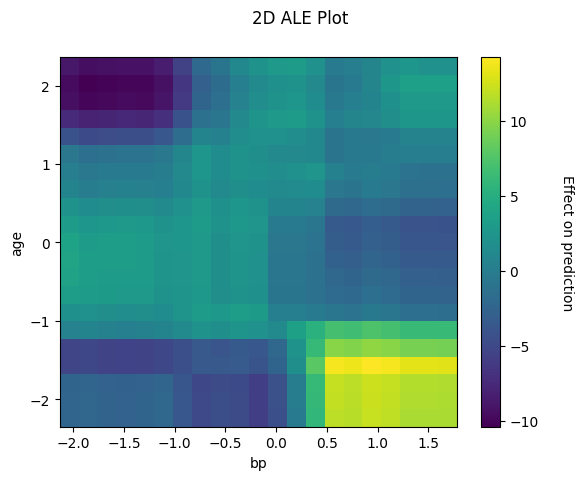

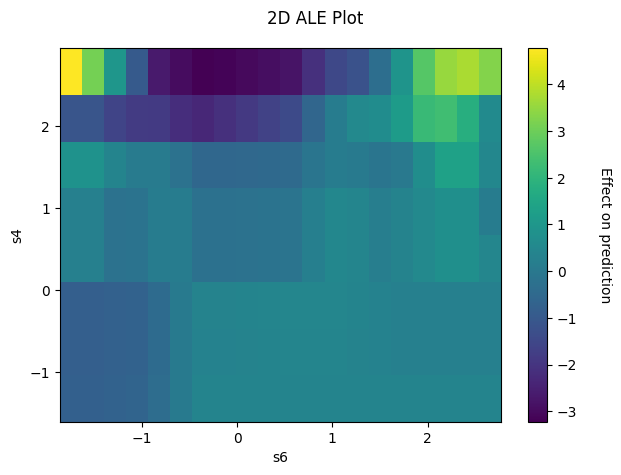

In [5]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from PyALE import ale
import matplotlib.pyplot as plt

# Carica il dataset
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

# Converti in DataFrame
import pandas as pd
X_df = pd.DataFrame(X, columns=feature_names)

# Split e standardizzazione
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_test_df = pd.DataFrame(X_test_scaled, columns=feature_names)

# Addestra Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# ALE plots per singole feature
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    ale_eff = ale(
        X=X_test_df,
        model=rf,
        feature=[feature],
        grid_size=50,
        include_CI=False
    )
    ax = axes[idx]
    ale_eff.plot(ax=ax)
    ax.set_title(f'ALE: {feature}')

plt.tight_layout()
plt.show()

# ALE plots 2D
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# ALE per age e bp
ale_eff_1 = ale(
    X=X_test_df,
    model=rf,
    feature=['age', 'bp'],
    grid_size=20,
    include_CI=False
)
ale_eff_1.plot(ax=ax1)
ax1.set_title('ALE: Age vs BP')

# ALE per s4 e s6
ale_eff_2 = ale(
    X=X_test_df,
    model=rf,
    feature=['s4', 's6'],
    grid_size=20,
    include_CI=False
)
ale_eff_2.plot(ax=ax2)
ax2.set_title('ALE: s4 vs s6')

plt.tight_layout()
plt.show()